In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
import seaborn as sns
import os
import shlex
import sys
from joblib import load
import glob 
import re


## loss and accuracy

In [2]:
res_dir = "results/logpolar"
res_files = glob.glob(os.path.join(res_dir, "results_*.pkl"))
res_files = [x for x in res_files if "num1-9" not in x]
res_files

['results/logpolar/results_pretrained_ventral-cnn-mse_hsize-1024_input-both_logpolar_num1-7_nl-0.74_policy-cheat+jitter_trainshapes-BCDEsame_distract012_logpolar_20_100000_loss-both_opt-Adam_drop0.5_sort_count-notA_300eps_rep0.pkl',
 'results/logpolar/results_rnn_classifier2stream_hsize-1024_input-both_logpolar_num1-7_nl-0.74_policy-cheat+jitter_trainshapes-BCDEsame__logpolar_12_100000_loss-both_opt-Adam_drop0.5_sort_count-notA_300eps_rep0.pkl',
 'results/logpolar/results_rnn_classifier2stream_hsize-1024_input-both_logpolar_num1-5_nl-0.74_policy-cheat+jitter_trainshapes-BCDEsame__logpolar_12_100000_loss-both_opt-Adam_drop0.5_sort_count-notA_300eps_rep0.pkl',
 'results/logpolar/results_pretrained_ventral-cnn-mse_hsize-1024_input-both_logpolar_num1-7_nl-0.74_policy-cheat+jitter_trainshapes-BCDEsame_distract012_logpolar_12_100000_loss-both_opt-Adam_drop0.5_sort_count-notA_300eps_rep0.pkl',
 'results/logpolar/results_pretrained_ventral-cnn-mse_hsize-1024_input-both_logpolar_num1-5_nl-0.74_

In [3]:
res_lists = {}
pattern = re.compile(r"results_(.*)_hsize.*num\d+-(\d+).*?logpolar_(\d+)", re.IGNORECASE)
shortmodelnames = {
    "pretrained_ventral-cnn-mse": "with distractor",
    "rnn_classifier2stream": "w.o. distractor"
}
for rf in res_files:
    res = load(rf)
    res["dataset"] = pd.Categorical(res["dataset"], categories = ["train","validation","ood"],ordered=True)
    match = pattern.search(rf)
    if match:
        taskname = shortmodelnames[match.group(1)]
        max_num = match.group(2)       # 'min' or 'max'
        n_glimpses = match.group(3)   # 'num'
    res_lists[f"{taskname}, 1-{max_num} obj, {n_glimpses} glimpses"] = res
        
    
# we have 300+1 epochs in total
loss_cols = ['count map loss','count num loss','dist map loss']
acc_cols = ['accuracy count']

res.columns

Index(['full map loss', 'dist map loss', 'count map loss', 'count num loss',
       'dist num loss', 'all num loss', 'shape loss', 'accuracy count',
       'accuracy dist', 'accuracy all', 'epoch', 'dataset', 'accuracy map',
       'viewing', 'test shapes', 'test lums'],
      dtype='object')

In [4]:
list(res_lists.keys())

['with distractor, 1-7 obj, 20 glimpses',
 'w.o. distractor, 1-7 obj, 12 glimpses',
 'w.o. distractor, 1-5 obj, 12 glimpses',
 'with distractor, 1-7 obj, 12 glimpses',
 'with distractor, 1-5 obj, 12 glimpses']

/tmp/ipykernel_1581514/1099665367.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for j, (ds, dsdf) in enumerate(res.groupby('dataset')):
/tmp/ipykernel_1581514/1099665367.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for j, (ds, dsdf) in enumerate(res.groupby('dataset')):
/tmp/ipykernel_1581514/1099665367.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for j, (ds, dsdf) in enumerate(res.groupby('dataset'))

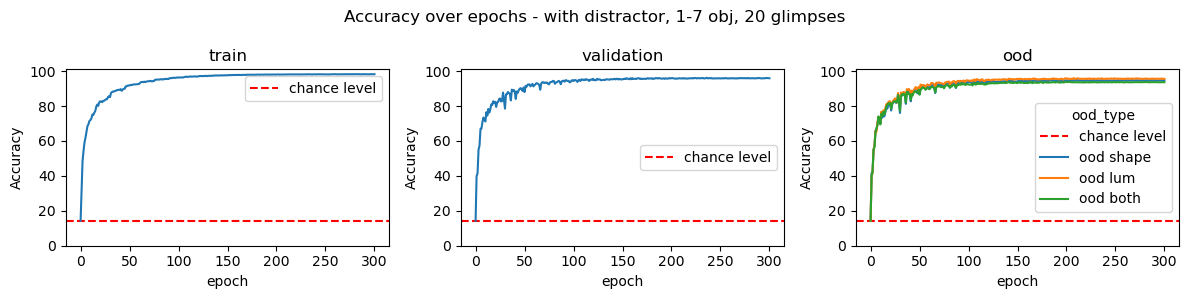

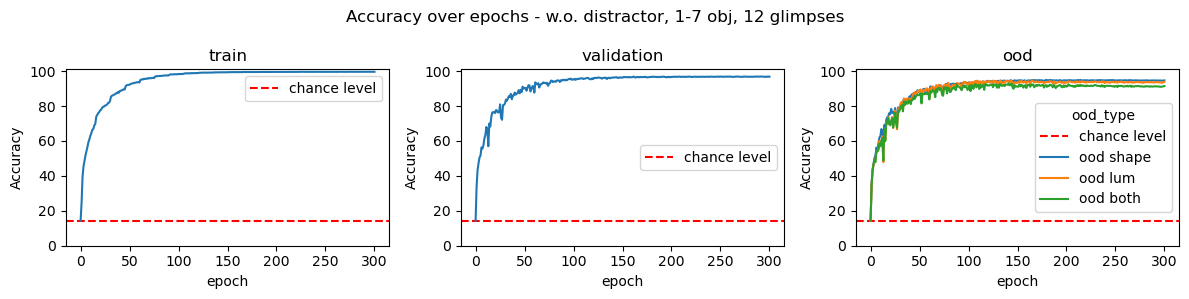

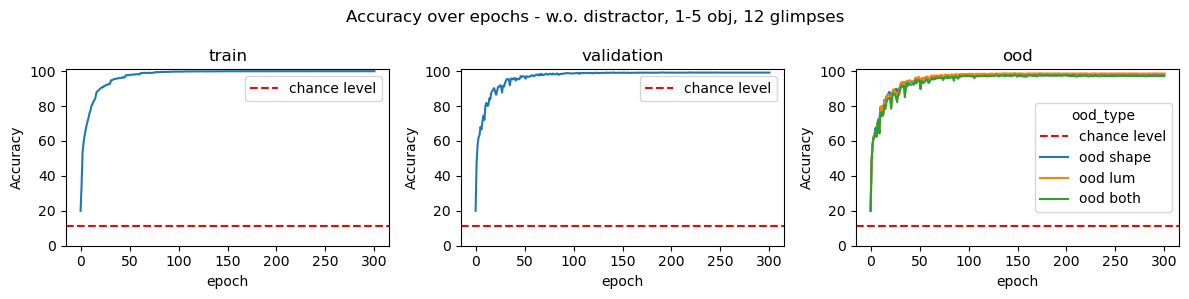

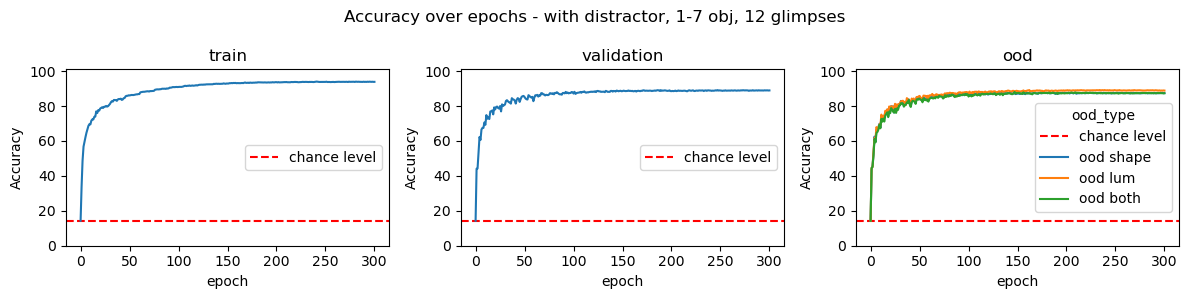

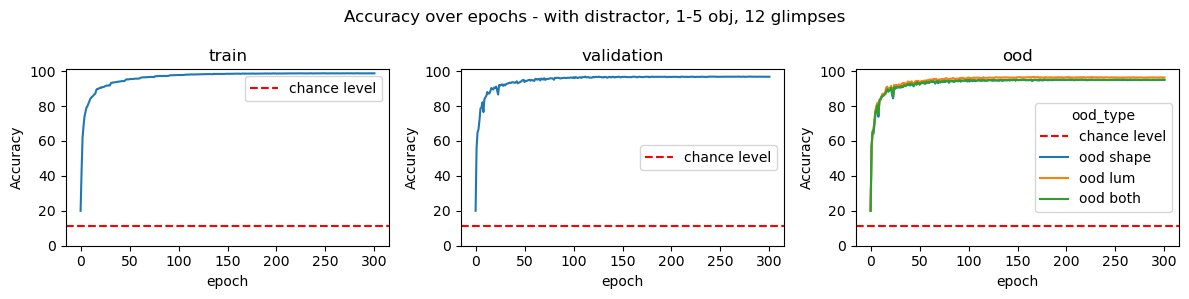

In [5]:
for rsname, res in res_lists.items():
    fig_acc, ax_acc = plt.subplots(1,3, figsize=(3*4, 3))
    for j, (ds, dsdf) in enumerate(res.groupby('dataset')):
        if "1-7" in rsname:
            chance_level = 100 * (1/7)
        else:
            chance_level = 100 * (1/9)
        ax_acc[j].axhline(chance_level, color='red', linestyle='--', label='chance level')
        
        if ds == "ood":
            # further split by test shapes and lums
            dsdf = dsdf.copy()
            dsdf['test shapes ood'] = [s == "['F', 'G', 'H', 'J']" for s in dsdf['test shapes']]
            dsdf['test lums ood'] = [l == "[0.3, 0.6, 0.9]" for l in dsdf['test lums']]
            dsdf['ood_type'] = ["ood shape" if np.logical_and(s, not l) else
                                "ood lum" if np.logical_and(not s, l) else
                                "ood both" if np.logical_and(s, l) else
                                "iid" for s, l in zip(dsdf['test shapes ood'], dsdf['test lums ood'])]
            sns.lineplot(data=dsdf, x='epoch', y='accuracy count', hue='ood_type', ax=ax_acc[j])
            

        else:
            sns.lineplot(data=dsdf, x='epoch', y='accuracy count', ax=ax_acc[j])
        
        ax_acc[j].set_ylim(0, 101)        
        ax_acc[j].set_title(ds)
        ax_acc[j].set_ylabel('Accuracy')

    fig_acc.suptitle(f'Accuracy over epochs - {rsname}')
    plt.tight_layout()

/tmp/ipykernel_1581514/3590317741.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for j, (ds, dsdf) in enumerate(res.groupby('dataset')):
/tmp/ipykernel_1581514/3590317741.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for j, (ds, dsdf) in enumerate(res.groupby('dataset')):
/tmp/ipykernel_1581514/3590317741.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for j, (ds, dsdf) in enumerate(res.groupby('dataset'))

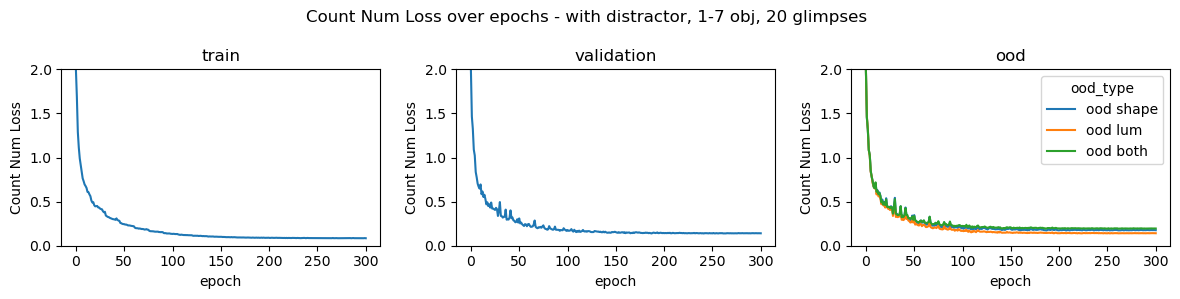

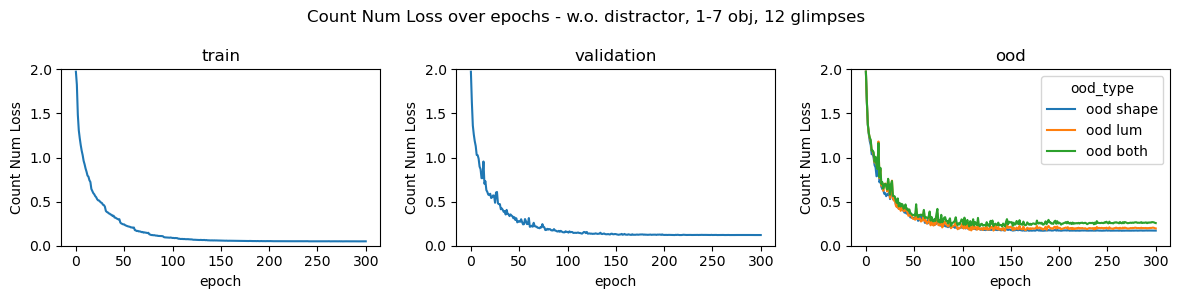

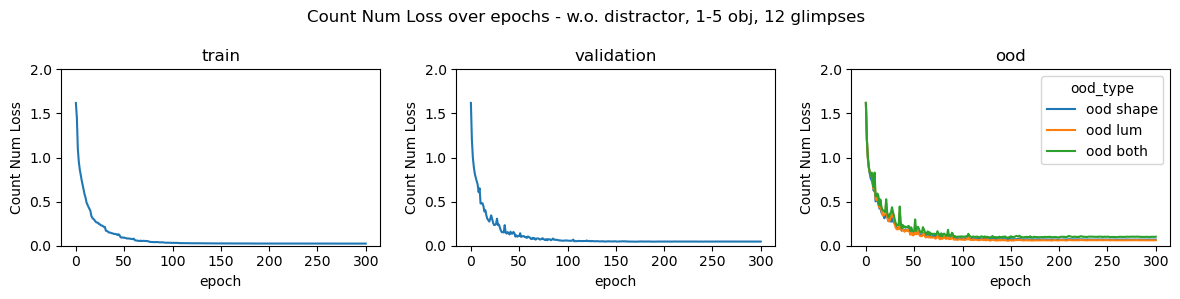

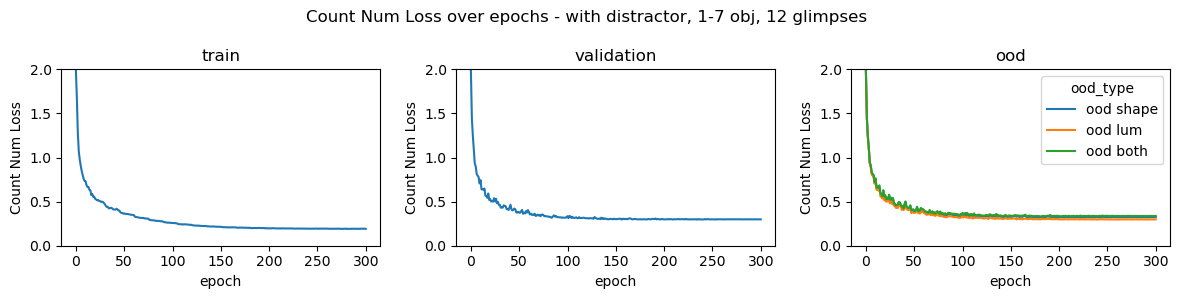

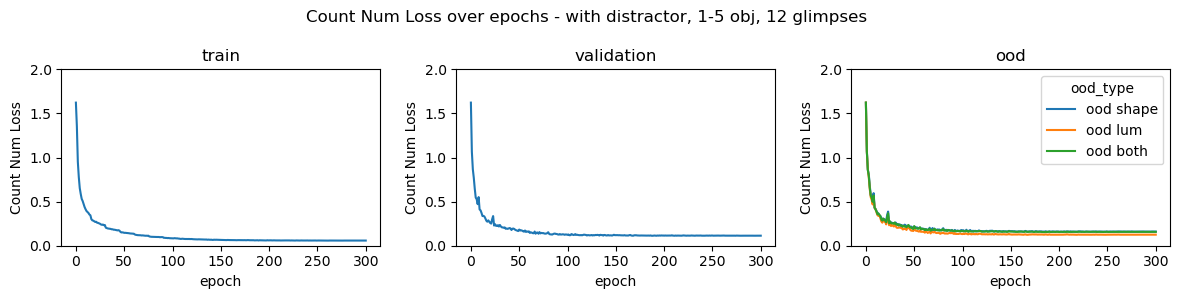

In [6]:
for rsname, res in res_lists.items():
    fig_acc, ax_acc = plt.subplots(1,3, figsize=(3*4, 3))
    for j, (ds, dsdf) in enumerate(res.groupby('dataset')):
        if ds == "ood":
            # further split by test shapes and lums
            dsdf = dsdf.copy()
            dsdf['test shapes ood'] = [s == "['F', 'G', 'H', 'J']" for s in dsdf['test shapes']]
            dsdf['test lums ood'] = [l == "[0.3, 0.6, 0.9]" for l in dsdf['test lums']]
            dsdf['ood_type'] = ["ood shape" if np.logical_and(s, not l) else
                                "ood lum" if np.logical_and(not s, l) else
                                "ood both" if np.logical_and(s, l) else
                                "iid" for s, l in zip(dsdf['test shapes ood'], dsdf['test lums ood'])]
            sns.lineplot(data=dsdf, x='epoch', y='count num loss', hue='ood_type', ax=ax_acc[j])

        else:
            sns.lineplot(data=dsdf, x='epoch', y='count num loss', ax=ax_acc[j])

        ax_acc[j].set_ylim(0, 2)
        ax_acc[j].set_title(ds)
        ax_acc[j].set_ylabel('Count Num Loss')

    fig_acc.suptitle(f'Count Num Loss over epochs - {rsname}')
    plt.tight_layout()

/tmp/ipykernel_1581514/4246770285.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for j, (ds, dsdf) in enumerate(res.groupby('dataset')):
/tmp/ipykernel_1581514/4246770285.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for j, (ds, dsdf) in enumerate(res.groupby('dataset')):
/tmp/ipykernel_1581514/4246770285.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for j, (ds, dsdf) in enumerate(res.groupby('dataset'))

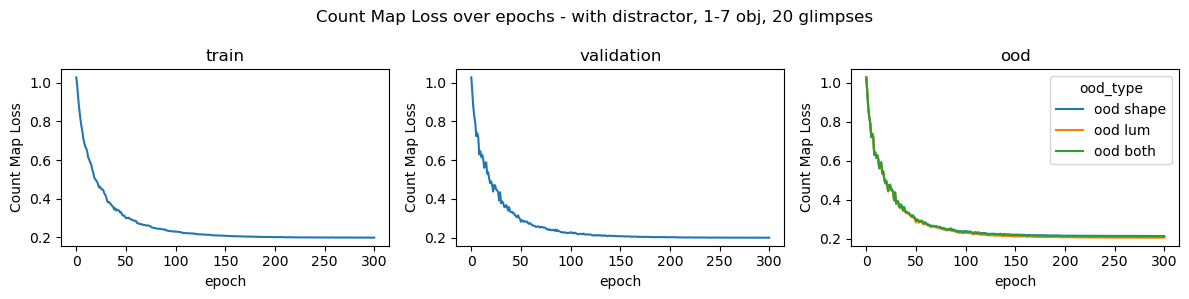

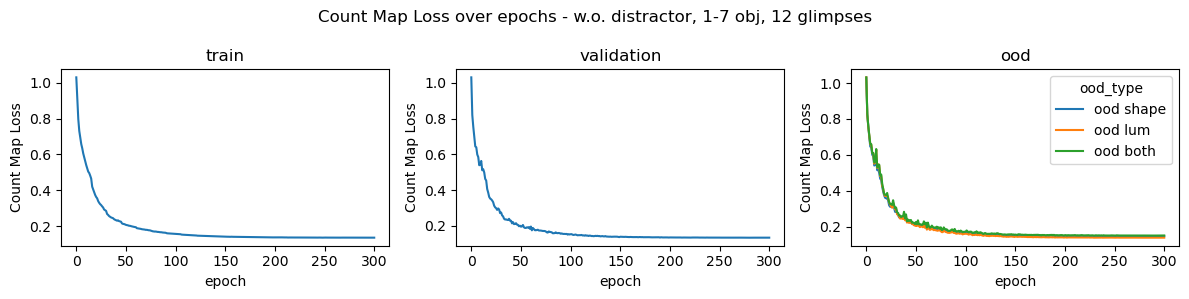

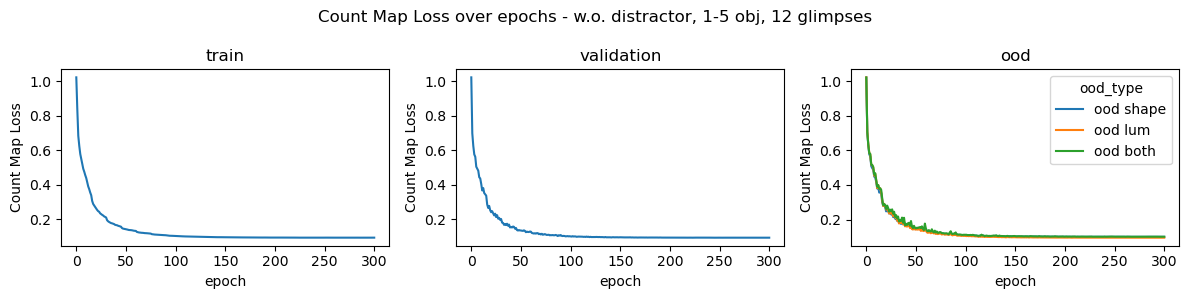

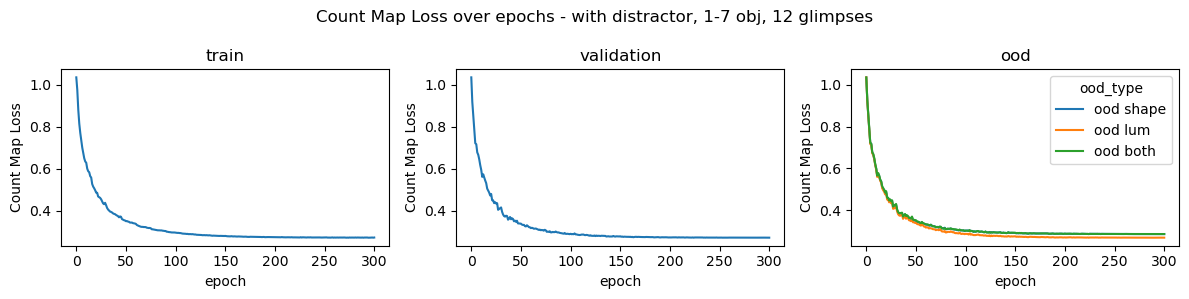

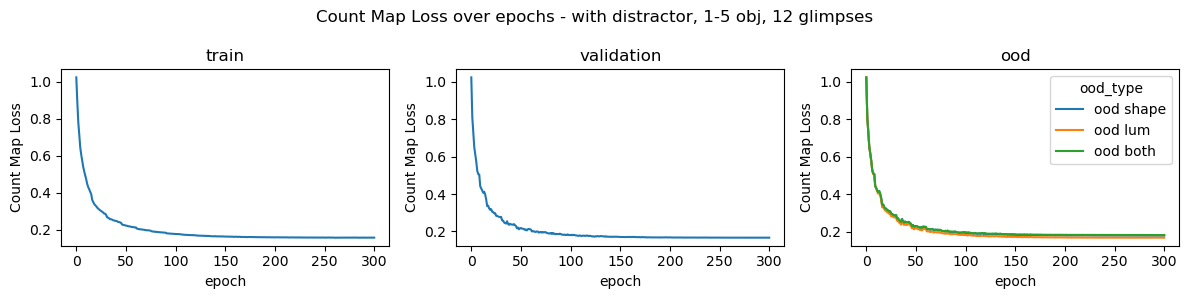

In [7]:
for rsname, res in res_lists.items():
    fig_acc, ax_acc = plt.subplots(1,3, figsize=(3*4, 3))
    for j, (ds, dsdf) in enumerate(res.groupby('dataset')):
        if ds == "ood":
            # further split by test shapes and lums
            dsdf = dsdf.copy()
            dsdf['test shapes ood'] = [s == "['F', 'G', 'H', 'J']" for s in dsdf['test shapes']]
            dsdf['test lums ood'] = [l == "[0.3, 0.6, 0.9]" for l in dsdf['test lums']]
            dsdf['ood_type'] = ["ood shape" if np.logical_and(s, not l) else
                                "ood lum" if np.logical_and(not s, l) else
                                "ood both" if np.logical_and(s, l) else
                                "iid" for s, l in zip(dsdf['test shapes ood'], dsdf['test lums ood'])]
            sns.lineplot(data=dsdf, x='epoch', y='count map loss', hue='ood_type', ax=ax_acc[j])

        else:
            sns.lineplot(data=dsdf, x='epoch', y='count map loss', ax=ax_acc[j])

        ax_acc[j].set_title(ds)
        ax_acc[j].set_ylabel('Count Map Loss')

    fig_acc.suptitle(f'Count Map Loss over epochs - {rsname}')
    plt.tight_layout()

In [16]:
res_dfs_final_epoch = []
for rsname, res in res_lists.items():
    pattern = re.compile(r"(.*), 1-(\d+) obj, (\d+) glimpses", re.IGNORECASE)
    match = pattern.search(rsname)
    taskname, maxnum, n_glimpses = match.group(1), match.group(2), match.group(3)

    res_final = res[res['epoch'] == res['epoch'].max()]
    res_final = res_final.copy()
    res_final['task'] = taskname
    res_final['saccond'] = "jitter"
    res_final["simname"] = f"num1-{maxnum}_glim{n_glimpses}"
    res_final['numrange'] = f"1-{maxnum}"
    res_final['n_glimpses'] = int(n_glimpses)

    print(res_final.shape)
    res_dfs_final_epoch.append(res_final)


(5, 21)
(5, 21)
(5, 21)
(5, 21)
(5, 21)


In [9]:
res_final["dataset"]

300         train
300    validation
300           ood
300           ood
300           ood
Name: dataset, dtype: category
Categories (3, object): ['train' < 'validation' < 'ood']

/tmp/ipykernel_1581514/2240327967.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for j, (ds, dsdf) in enumerate(taskdf.groupby('dataset')):
/tmp/ipykernel_1581514/2240327967.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for j, (ds, dsdf) in enumerate(taskdf.groupby('dataset')):


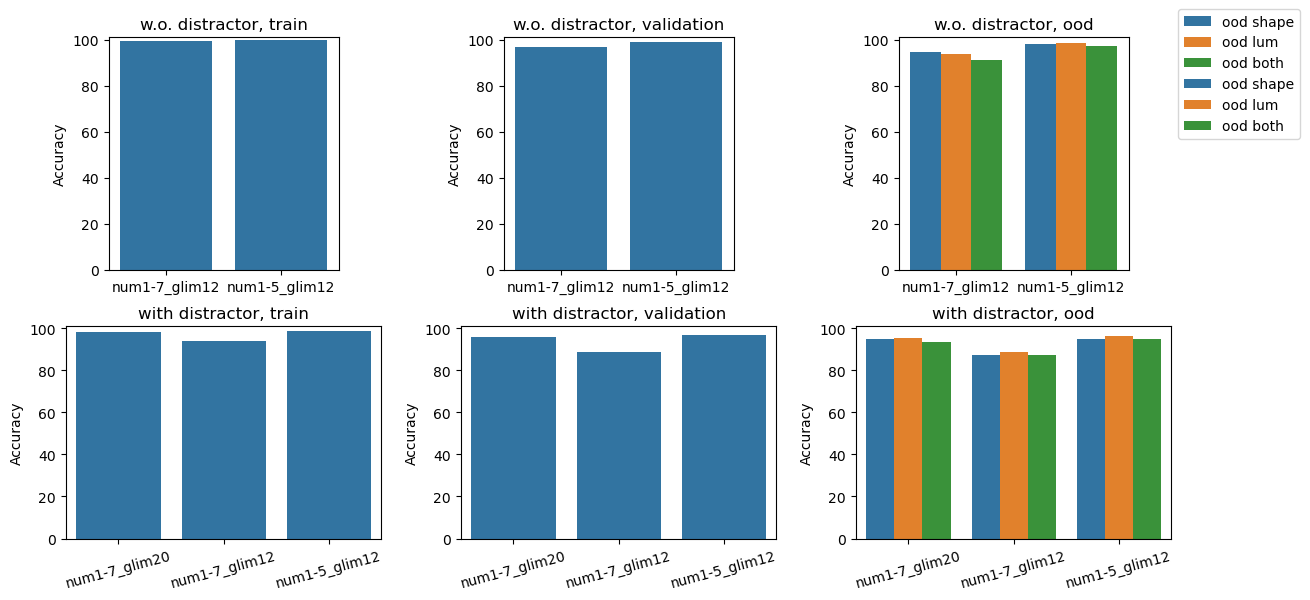

In [17]:
res_df_final_epoch = pd.concat(res_dfs_final_epoch).reset_index(drop=True)
res_df_final_epoch.to_csv("saccade_models_final_epoch_results_2025Oct20.csv", index=False)
fig_acc, ax_acc = plt.subplots(2,3, figsize=(4*3, 3*2))
for k, (taskname, taskdf) in enumerate(res_df_final_epoch.groupby('task')):
    for j, (ds, dsdf) in enumerate(taskdf.groupby('dataset')):
        if ds == "ood":
            # further split by test shapes and lums
            dsdf = dsdf.copy()
            dsdf['test shapes ood'] = [s == "['F', 'G', 'H', 'J']" for s in dsdf['test shapes']]
            dsdf['test lums ood'] = [l == "[0.3, 0.6, 0.9]" for l in dsdf['test lums']]
            dsdf['ood_type'] = ["ood shape" if np.logical_and(s, not l) else
                                "ood lum" if np.logical_and(not s, l) else
                                "ood both" if np.logical_and(s, l) else
                                "iid" for s, l in zip(dsdf['test shapes ood'], dsdf['test lums ood'])]
            sns.barplot(data=dsdf, x='simname', y='accuracy count', hue='ood_type', ax=ax_acc[k,j])

        else:
            sns.barplot(data=dsdf, x='simname', y='accuracy count', ax=ax_acc[k,j])

        ax_acc[k,j].set_ylim(0, 101)
        ax_acc[k,j].set_xlabel("")
        if k == 0:
            ax_acc[k,j].set_aspect(.02)
        else:
            ax_acc[k,j].set_aspect(.02)
            ax_acc[k,j].tick_params(axis='x', rotation=15)
        ax_acc[k,j].set_title(f"{taskname}, {ds}")
        ax_acc[k,j].set_ylabel('Accuracy')
    ax_acc[k,j].legend_.remove()

fig_acc.legend(bbox_to_anchor=(0.98, 1), loc='upper left')
fig_acc.tight_layout()
#sns.catplot(data=res_df_final_epoch, x='simname', y='accuracy count', hue='max_num',
#            col='task', row='dataset', kind='bar', height=4, aspect=1)
#.to_csv("saccade_models_final_epoch_results_2025Oct20.csv", index=False)

## confusion matrix

In [34]:
conf_dir = "results/logpolar"
conf_files = glob.glob(os.path.join(conf_dir, "confusion_*.npy"))
conf_files = [f for f in conf_files if ("1-9" not in f) and ("at_" not in f)]
conf_files = [f for f in conf_files if "1-7" in f]

In [41]:
for conf_file in conf_files:
    conf = np.load(conf_file)
    match = pattern.search(conf_file)
    res_name = ""
    if match:
        task_type = match.group(1)   # 'min' or 'max'
        loss_type = match.group(2)   # 'num'
        res_name = f"{task_type} task, {loss_type} loss"
        print(res_name)

In [50]:
res.viewing.unique()
len(conf[-1][0])
np.shape(conf)
#[f"{x+1}" for x in range(c.shape[0])]

(301, 4, 3, 7, 7)

[[[238.   0.   0.   0.   0.   0.   0.]
  [  0. 238.   0.   0.   0.   0.   0.]
  [  0.   0. 235.   3.   0.   0.   0.]
  [  0.   0.   6. 228.   4.   0.   0.]
  [  0.   0.   0.   8. 214.  16.   0.]
  [  0.   0.   0.   0.  29. 182.  27.]
  [  0.   0.   0.   0.   0.  44. 194.]]

 [[238.   0.   0.   0.   0.   0.   0.]
  [  0. 237.   1.   0.   0.   0.   0.]
  [  0.   3. 233.   1.   1.   0.   0.]
  [  0.   0.  12. 217.   9.   0.   0.]
  [  0.   0.   0.  12. 212.  14.   0.]
  [  0.   0.   0.   2.  46. 155.  36.]
  [  0.   0.   0.   0.   6.  51. 181.]]

 [[238.   0.   0.   0.   0.   0.   0.]
  [  0. 237.   1.   0.   0.   0.   0.]
  [  0.   4. 230.   4.   0.   0.   0.]
  [  0.   0.   9. 216.  13.   0.   0.]
  [  0.   0.   0.  37. 184.  17.   0.]
  [  0.   0.   0.   1.  37. 164.  36.]
  [  0.   0.   0.   0.   3.  61. 175.]]]
Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/home/liangz/miniconda3/envs/newsac/lib/python3.13/site-packages/IPython/core/interactiveshell.py", line 3699, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
    ~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_1581514/877242258.py", line 16, in <module>
    sns.heatmap(c*100 / c.sum(axis=1, keepdims=True), annot=True, fmt=".1f", ax=ax)
    ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/liangz/miniconda3/envs/newsac/lib/python3.13/site-packages/seaborn/matrix.py", line 446, in heatmap
    plotter = _HeatMapper(data, vmin, vmax, cmap, center, robust, annot, fmt,
                          annot_kws, cbar, cbar_kws, xticklabels,
                          yticklabels, mask)
  File "/home/liangz/miniconda3/envs/newsac/lib/python3.13/site-packages/seaborn/matrix.py", line 110, in __init__
    data = pd.DataFrame(plot_data)
  File "/home/liangz/miniconda3/envs/n

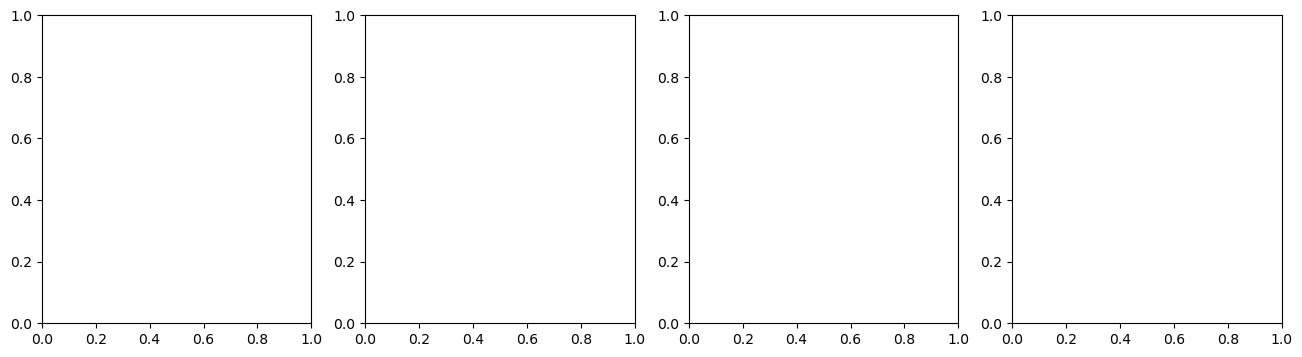

In [46]:
# plt.subplots(1,4, figsize=(4*4,4))
# # the four confusion matrices corresponded to: [val_free, ood_shape_free, ood_lum_free, ood_both_free]
# conf_names = ['validation', 'ood_shape', 'ood_lum', 'ood_both']
# for i, c in enumerate(conf[-1]):
#     ax = plt.subplot(1, 4, i+1)
#     sns.heatmap(c, ax=ax)
#     ax.set_title(f'Confusion Matrix at Final Epoch \n{res_name}')


plt.subplots(1,4, figsize=(4*4,4))
# the four confusion matrices corresponded to: [val_free, ood_shape_free, ood_lum_free, ood_both_free]
conf_names = ['validation', 'ood_shape', 'ood_lum', 'ood_both']
for i, (cname,c) in enumerate(zip(conf_names,conf[-1])):
    ax = plt.subplot(1, 4, i+1)
    print(c)
    sns.heatmap(c*100 / c.sum(axis=1, keepdims=True), annot=True, fmt=".1f", ax=ax)
    ax.set_title(f'Confusion Matrix at Final Epoch \n{cname}')
    ax.set_xticklabels(labels=[f"{x+1}" for x in range(c.shape[0])])
    ax.set_xlabel('Predicted Min')
    ax.set_ylabel('True Min')

plt.tight_layout()

/tmp/ipykernel_8789/2006727965.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes_ill[1].set_xticklabels([' 4', '3', '2', '1 '])
/tmp/ipykernel_8789/2006727965.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes_ill[1].set_xticklabels([' 4', '3', '2', '1 '])
/tmp/ipykernel_8789/2006727965.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes_ill[1].set_xticklabels([' 4', '3', '2', '1 '])
/tmp/ipykernel_8789/2006727965.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes_ill[1].set_xticklabels([' 4', '3', '2', '1 '])


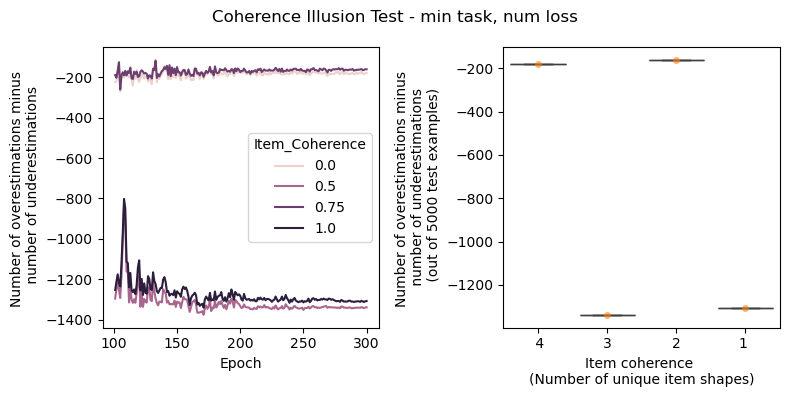

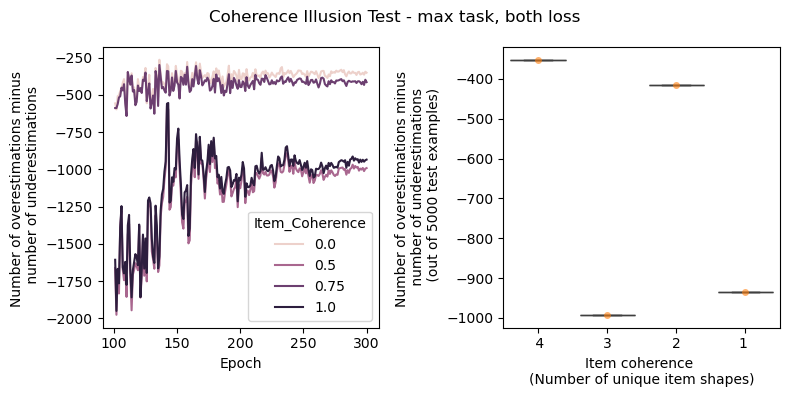

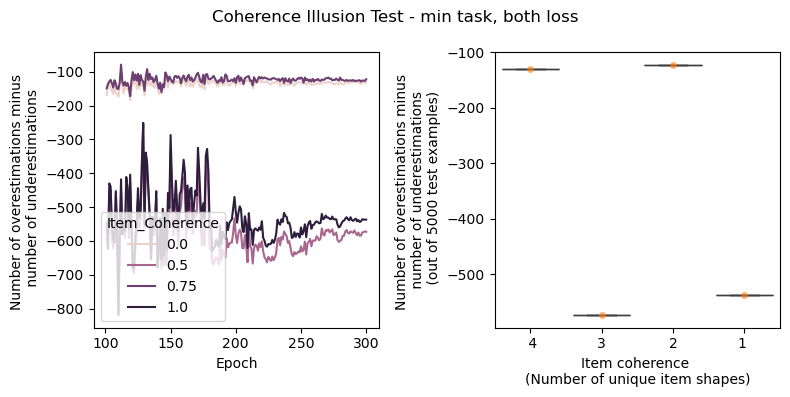

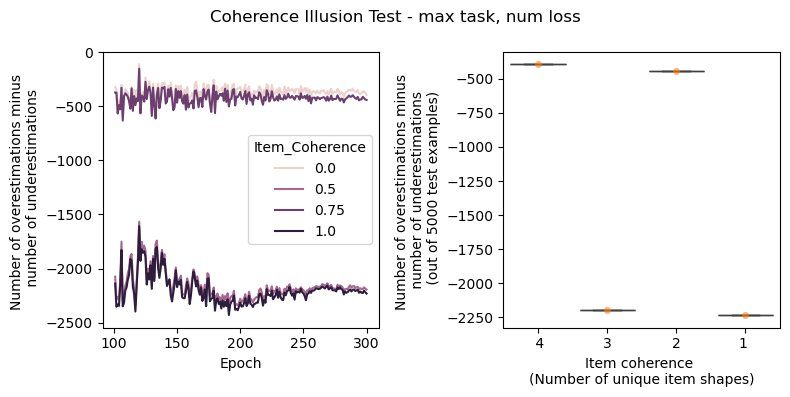

In [ ]:
for conf_file in conf_files:
    conf = np.load(conf_file) # conf is of shape (n_epochs+1, 4, n_classes, n_classes)
    match = pattern.search(conf_file)
    res_name = ""
    if match:
        task_type = match.group(1)       # 'min' or 'max'
        loss_type = match.group(2)   # 'num'
        res_name = f"{task_type} task, {loss_type} loss"

    entries = []
    for ep, mat in enumerate(conf):
        # [diff1_loader, diff06_loader, diff03_loader, same_loader]
        diff_conf = mat[0, :, :]
        diff06_conf = mat[1, :, :]
        diff03_conf = mat[2, :, :]
        same_conf = mat[3, :, :]

        diffover = diff_conf[np.triu_indices_from(diff_conf, k=1)].sum()
        diffunder = diff_conf[np.tril_indices_from(diff_conf, k=-1)].sum()
        diff06over = diff06_conf[np.triu_indices_from(diff06_conf, k=1)].sum()
        diff06under = diff06_conf[np.tril_indices_from(diff06_conf, k=-1)].sum()
        diff03over = diff03_conf[np.triu_indices_from(diff03_conf, k=1)].sum()
        diff03under = diff03_conf[np.tril_indices_from(diff03_conf, k=-1)].sum()
        sameover = same_conf[np.triu_indices_from(same_conf, k=1)].sum()
        sameunder = same_conf[np.tril_indices_from(same_conf, k=-1)].sum()
        entries.append({'Item_Coherence':0, 'Over-Under': diffover-diffunder, 'Epoch':ep})
        entries.append({'Item_Coherence':2/4, 'Over-Under': diff06over-diff06under, 'Epoch':ep})
        entries.append({'Item_Coherence':3/4, 'Over-Under': diff03over-diff03under, 'Epoch':ep})
        entries.append({'Item_Coherence':1, 'Over-Under': sameover-sameunder, 'Epoch':ep})
    

    df = pd.DataFrame(entries)
    fig_ill, axes_ill = plt.subplots(1,2, figsize=(8,4))
    sns.lineplot(data=df[df.Epoch>100], y='Over-Under', x='Epoch', hue='Item_Coherence', ax=axes_ill[0])
    #axes_ill[0].set_title('Coherence Illusion Test')
    axes_ill[0].set_ylabel('Number of overestimations minus \n number of underestimations')

    last_epoch = df[df.Epoch==300]
    sns.boxplot(data=last_epoch, y='Over-Under', x='Item_Coherence', ax=axes_ill[1])
    sns.stripplot(data=last_epoch, y='Over-Under', x='Item_Coherence', ax=axes_ill[1], dodge=True, alpha=0.6)
    ticks = [-40, -20, 0, 20, 40]
    # ax.set_yticks(ticks, labels=[t/50 for t in ticks])
    axes_ill[1].set_ylabel('Number of overestimations minus \n number of underestimations \n (out of 5000 test examples)')
    # ax.set_title('Coherence illusion test')
    axes_ill[1].set_xlabel('Item coherence \n(Number of unique item shapes)')
    axes_ill[1].set_xticklabels([' 4', '3', '2', '1 '])

    fig_ill.suptitle(f'Coherence Illusion Test - {res_name}')
    plt.tight_layout()

